1. Charger les 3 versions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv("../data/raw/donnees_retail.csv")
df_eda = pd.read_csv("../data/processed/step1_exploration.csv") 
df_clean = pd.read_csv("../data/processed/step2_cleaning.csv")

2. Comparer valeurs manquantes

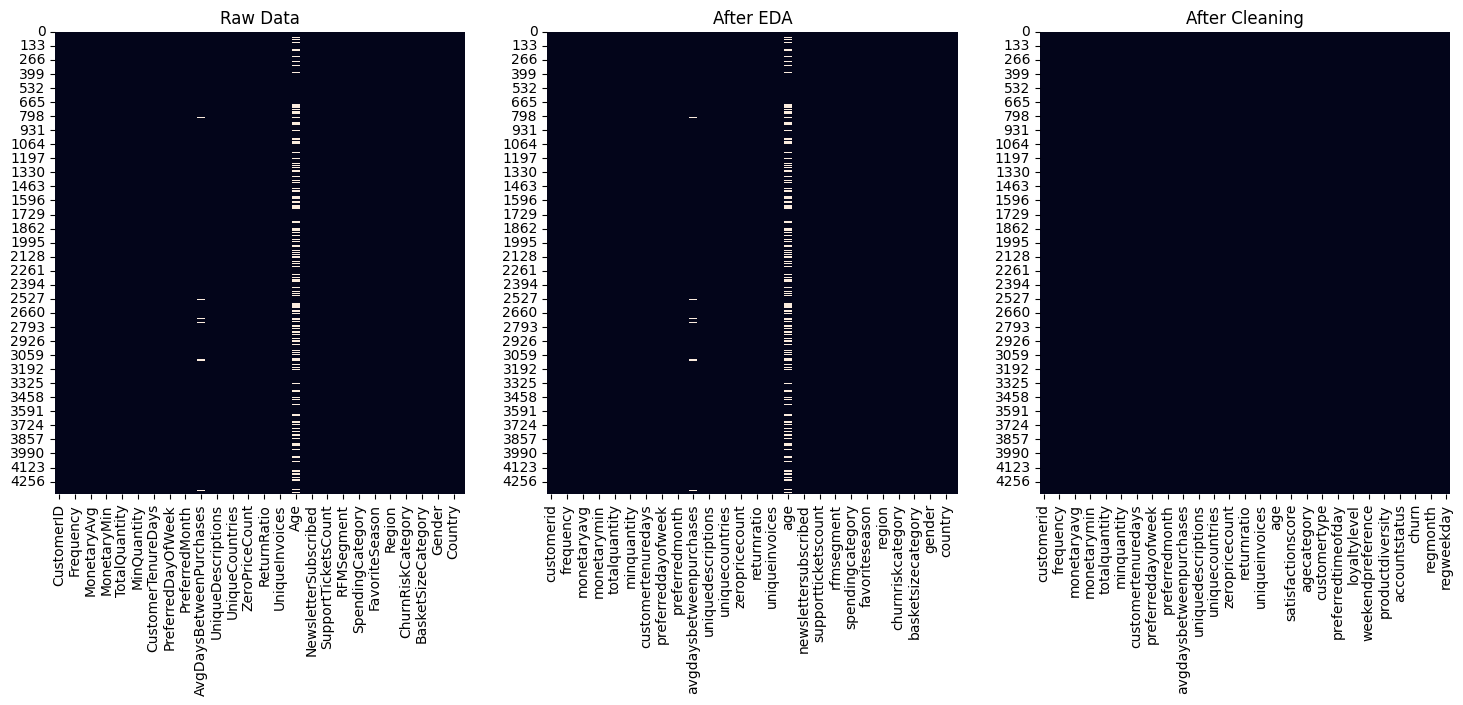

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.heatmap(df_raw.isnull(), cbar=False, ax=axes[0])
axes[0].set_title("Raw Data")

sns.heatmap(df_eda.isnull(), cbar=False, ax=axes[1])
axes[1].set_title("After EDA")

sns.heatmap(df_clean.isnull(), cbar=False, ax=axes[2])
axes[2].set_title("After Cleaning")

plt.show()


3. Comparer distribution de features clés

In [4]:
plt.figure(figsize=(12,5))
sns.kdeplot(df_raw['age'], label='Raw', shade=True)
sns.kdeplot(df_eda['age'], label='After EDA', shade=True)
sns.kdeplot(df_clean['age'], label='After Cleaning', shade=True)
plt.title("Comparaison distribution de age")
plt.legend()
plt.show()


KeyError: 'age'

<Figure size 1200x500 with 0 Axes>

In [5]:
nan_raw = df_raw.isnull().sum()
nan_clean = df_clean.isnull().sum()

nan_comparison = pd.DataFrame({
    "NaN_Raw": nan_raw,
    "NaN_Clean": nan_clean
})

# garder seulement les colonnes concernées
nan_comparison = nan_comparison[(nan_comparison["NaN_Raw"] > 0) | (nan_comparison["NaN_Clean"] > 0)]

nan_comparison.sort_values(by="NaN_Raw", ascending=False)


,NaN_Raw,NaN_Clean
Age,1311.0,NaN
AvgDaysBetweenPurchases,79.0,NaN


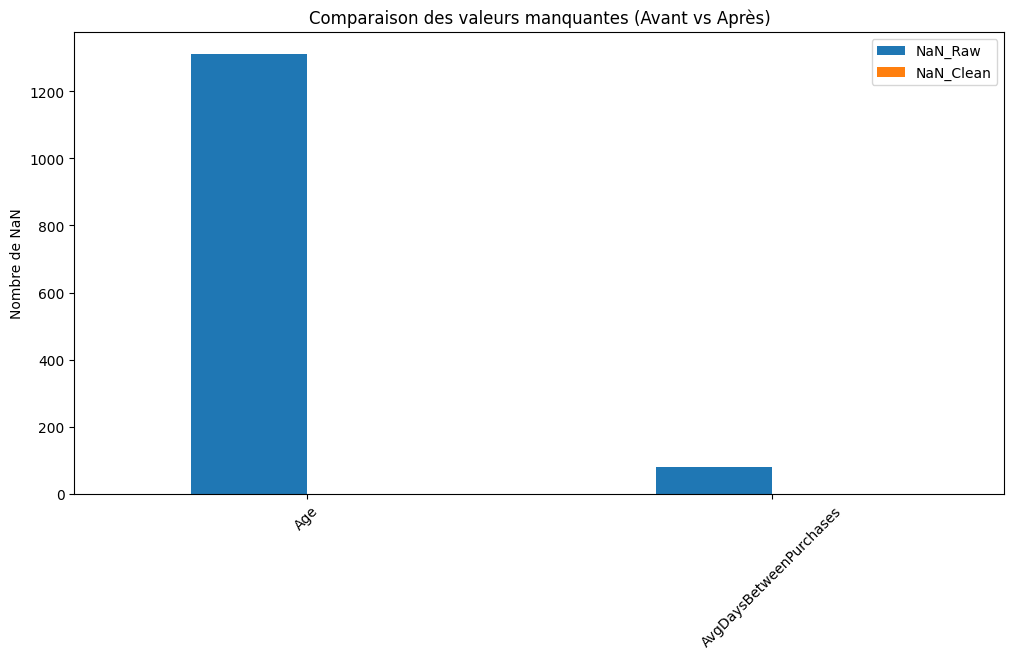

=== Raw Dataset ===
         CustomerID      Recency    Frequency  MonetaryTotal  MonetaryAvg  \
count   4372.000000  4372.000000  4372.000000    4372.000000  4372.000000   
mean   15299.677722    92.047118     5.075480    1898.459701    28.839013   
std     1722.390705   100.765435     9.338754    8219.345141   127.323926   
min    12346.000000     1.000000     1.000000   -4287.630000 -4287.630000   
25%    13812.750000    17.000000     1.000000     293.362500    10.985960   
50%    15300.500000    50.000000     3.000000     648.075000    16.918616   
75%    16778.250000   143.000000     5.000000    1611.725000    23.542941   
max    18287.000000   374.000000   248.000000  279489.020000  3861.000000   

         MonetaryStd    MonetaryMin    MonetaryMax  TotalQuantity  \
count    4372.000000    4372.000000    4372.000000    4372.000000   
mean       88.672383     -86.425754     185.179522    1122.344007   
std      2689.001161    2876.398935    2881.283699    4672.790720   
min       

In [7]:
nan_comparison.plot(kind='bar', figsize=(12,6))
plt.title("Comparaison des valeurs manquantes (Avant vs Après)")
plt.ylabel("Nombre de NaN")
plt.xticks(rotation=45)
plt.show()

# Comparaison statistique
print("=== Raw Dataset ===")
print(df_raw.describe())

print("\n=== Clean Dataset ===")
print(df_clean.describe())


KeyError: 'Age'

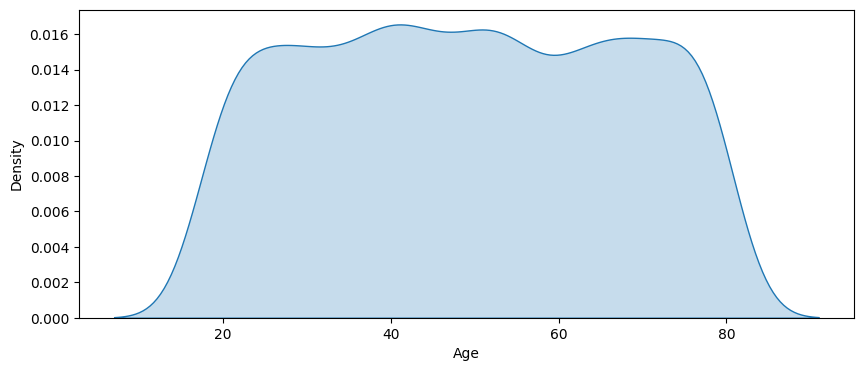

In [8]:
features = ['Age', 'SupportTicketsCount']

for col in features:
    plt.figure(figsize=(10,4))
    
    sns.kdeplot(df_raw[col], label="Raw", fill=True)
    sns.kdeplot(df_clean[col], label="Clean", fill=True)
    
    plt.title(f"Distribution de {col} (Avant vs Après)")
    plt.legend()
    plt.show()


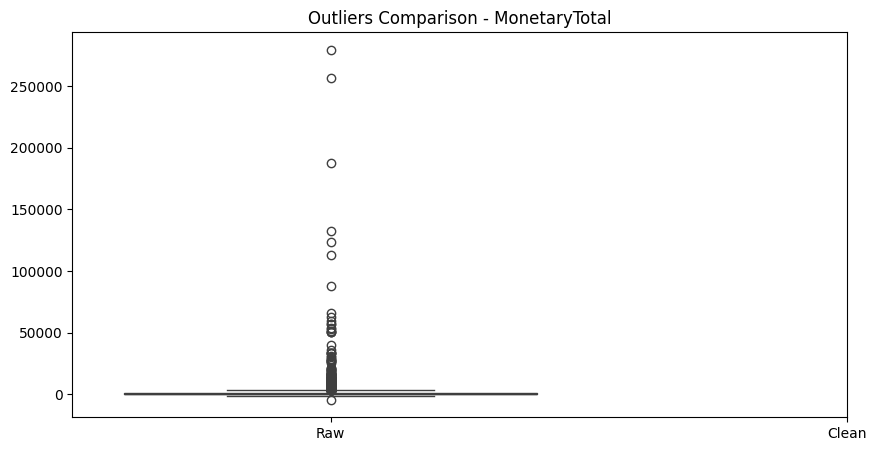

In [ ]:
# Comparaison des outliers
plt.figure(figsize=(10,5))

sns.boxplot(data=[df_raw['MonetaryTotal'], df_clean['MonetaryTotal']])
plt.xticks([0,1], ['Raw', 'Clean'])
plt.title("Outliers Comparison - MonetaryTotal")

plt.show()